# Methanol Properties and Phase Behaviour

This notebook explores the thermodynamic and physical properties of methanol (CH₃OH)
using NeqSim with the CPA (Cubic Plus Association) equation of state.

## Topics Covered
1. **Pure methanol properties** — vapor pressure, density, Cp from CPA EOS
2. **Methanol-water VLE** — highly non-ideal system with strong hydrogen bonding
3. **Methanol-hydrocarbon LLE** — liquid-liquid equilibrium for extraction applications
4. **Methanol as hydrate inhibitor** — phase behavior with natural gas

## Background

Methanol is one of the most important industrial chemicals:
- **Chemical feedstock** (formaldehyde, MTBE, acetic acid)
- **Fuel** and fuel additive (methanol-to-gasoline, marine fuel)
- **Hydrate inhibitor** in gas production (thermodynamic inhibitor)
- **Solvent** for CO₂ absorption (Rectisol process)
- **Hydrogen carrier** (methanol reforming)

| Property | Value |
|----------|-------|
| Molecular weight | 32.04 g/mol |
| Critical temperature | 239.5°C (512.6 K) |
| Critical pressure | 80.9 bara |
| Normal boiling point | 64.7°C |
| LHV | 19.9 MJ/kg |

Methanol is a strongly polar molecule with hydrogen bonding. The **CPA EOS** is
essential for accurate property prediction, especially in mixtures with water.

In [1]:
# Setup NeqSim
import subprocess, sys
try:
    from neqsim import jneqsim
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'neqsim'])
    from neqsim import jneqsim

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SystemSrkCPAstatoil = jneqsim.thermo.system.SystemSrkCPAstatoil
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations

print('NeqSim loaded successfully')

NeqSim loaded successfully


## 1. Pure Methanol Vapor Pressure

Compare SRK and CPA predictions of methanol vapor pressure against reference data.

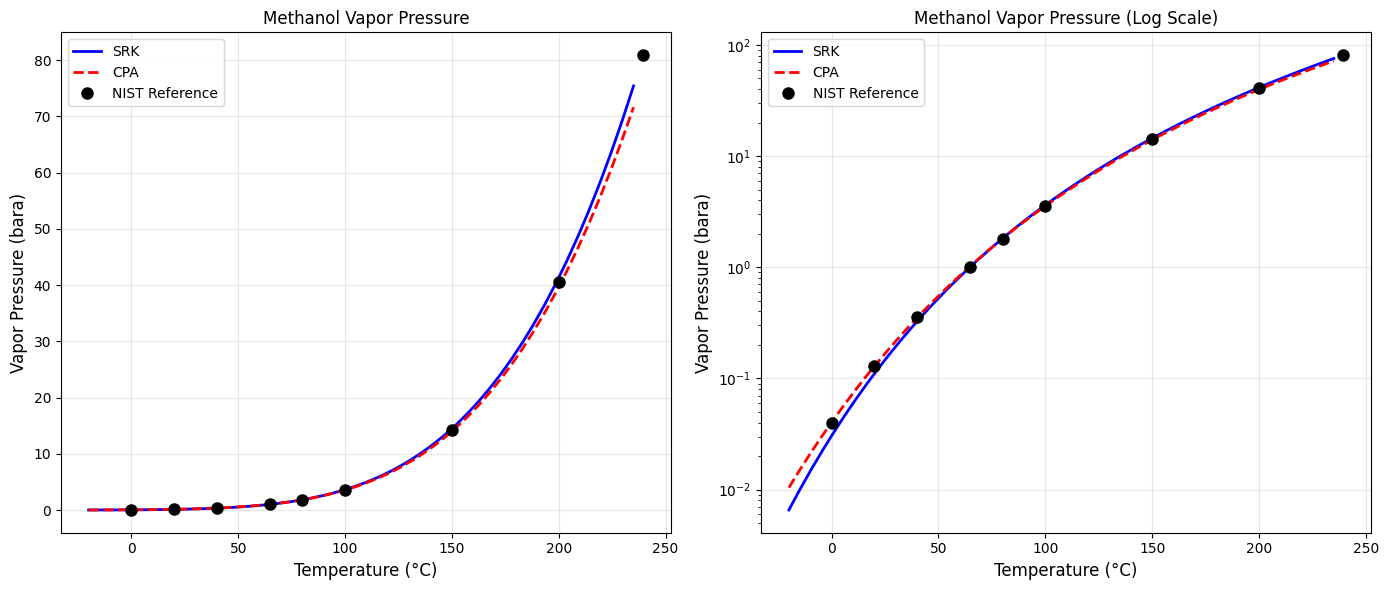

In [2]:
# Vapor pressure curve for pure methanol
temperatures = np.linspace(-20, 235, 50)

p_sat_srk = []
p_sat_cpa = []

for t in temperatures:
    for eos_name, eos_class, results_list in [('SRK', SystemSrkEos, p_sat_srk),
                                               ('CPA', SystemSrkCPAstatoil, p_sat_cpa)]:
        try:
            fluid = eos_class(273.15 + float(t), 5.0)
            fluid.addComponent('methanol', 1.0)
            fluid.setMixingRule('classic')
            ops = ThermodynamicOperations(fluid)
            ops.bubblePointPressureFlash(False)
            results_list.append(fluid.getPressure('bara'))
        except Exception:
            results_list.append(float('nan'))

# NIST reference data
nist_T = [0, 20, 40, 64.7, 80, 100, 150, 200, 239.5]
nist_P = [0.040, 0.129, 0.354, 1.013, 1.80, 3.55, 14.2, 40.5, 80.9]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.plot(temperatures, p_sat_srk, 'b-', label='SRK', linewidth=2)
ax1.plot(temperatures, p_sat_cpa, 'r--', label='CPA', linewidth=2)
ax1.plot(nist_T, nist_P, 'ko', label='NIST Reference', markersize=8)
ax1.set_xlabel('Temperature (°C)', fontsize=12)
ax1.set_ylabel('Vapor Pressure (bara)', fontsize=12)
ax1.set_title('Methanol Vapor Pressure')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.semilogy(temperatures, p_sat_srk, 'b-', label='SRK', linewidth=2)
ax2.semilogy(temperatures, p_sat_cpa, 'r--', label='CPA', linewidth=2)
ax2.semilogy(nist_T, nist_P, 'ko', label='NIST Reference', markersize=8)
ax2.set_xlabel('Temperature (°C)', fontsize=12)
ax2.set_ylabel('Vapor Pressure (bara)', fontsize=12)
ax2.set_title('Methanol Vapor Pressure (Log Scale)')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('methanol_vapor_pressure.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Methanol-Water VLE (T-xy Diagram)

The methanol-water system shows significant positive deviation from Raoult's law
due to disruption of water hydrogen-bond networks. CPA EOS can capture this.

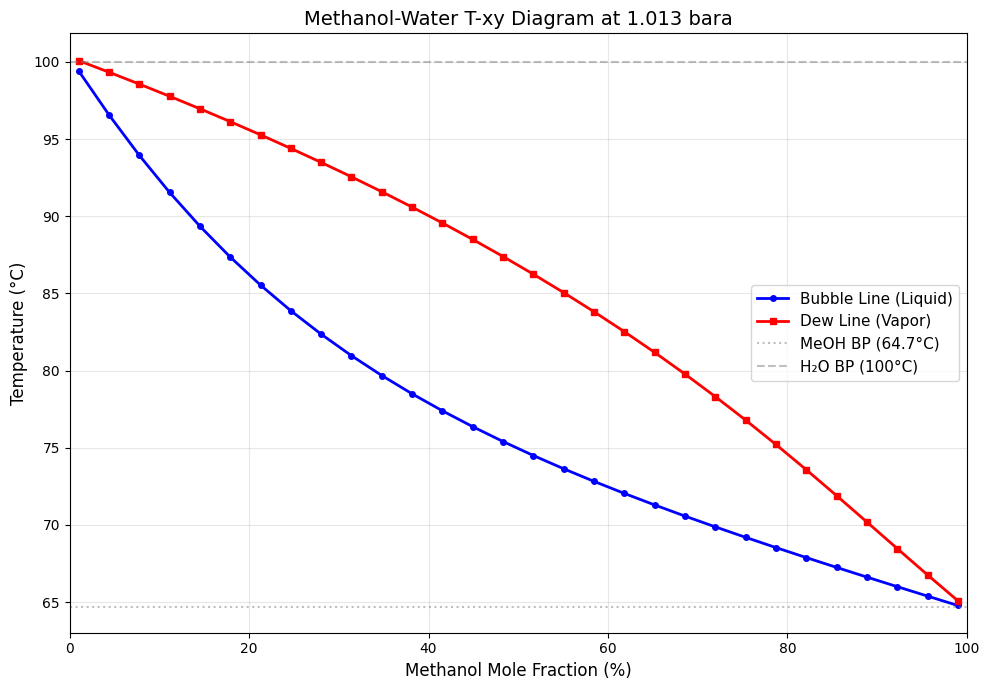

In [3]:
# Methanol-Water T-xy diagram at 1 atm
P_atm = 1.013  # bara
x_meoh = np.linspace(0.01, 0.99, 30)

T_bubble = []
T_dew = []

for x in x_meoh:
    try:
        # Bubble point
        fluid_b = SystemSrkCPAstatoil(273.15 + 70.0, P_atm)
        fluid_b.addComponent('methanol', float(x))
        fluid_b.addComponent('water', float(1.0 - x))
        fluid_b.setMixingRule('classic')
        ops_b = ThermodynamicOperations(fluid_b)
        ops_b.bubblePointTemperatureFlash()
        T_bubble.append(fluid_b.getTemperature() - 273.15)
    except Exception:
        T_bubble.append(float('nan'))

    try:
        # Dew point
        fluid_d = SystemSrkCPAstatoil(273.15 + 70.0, P_atm)
        fluid_d.addComponent('methanol', float(x))
        fluid_d.addComponent('water', float(1.0 - x))
        fluid_d.setMixingRule('classic')
        ops_d = ThermodynamicOperations(fluid_d)
        ops_d.dewPointTemperatureFlash()
        T_dew.append(fluid_d.getTemperature() - 273.15)
    except Exception:
        T_dew.append(float('nan'))

fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(x_meoh * 100, T_bubble, 'b-o', label='Bubble Line (Liquid)', linewidth=2, markersize=4)
ax.plot(x_meoh * 100, T_dew, 'r-s', label='Dew Line (Vapor)', linewidth=2, markersize=4)

ax.set_xlabel('Methanol Mole Fraction (%)', fontsize=12)
ax.set_ylabel('Temperature (°C)', fontsize=12)
ax.set_title(f'Methanol-Water T-xy Diagram at {P_atm} bara', fontsize=14)
ax.axhline(y=64.7, color='gray', linestyle=':', alpha=0.5, label='MeOH BP (64.7°C)')
ax.axhline(y=100.0, color='gray', linestyle='--', alpha=0.5, label='H₂O BP (100°C)')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_xlim(0, 100)

plt.tight_layout()
plt.savefig('methanol_water_txy.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Methanol Density and Transport Properties

Calculate key engineering properties at various conditions.

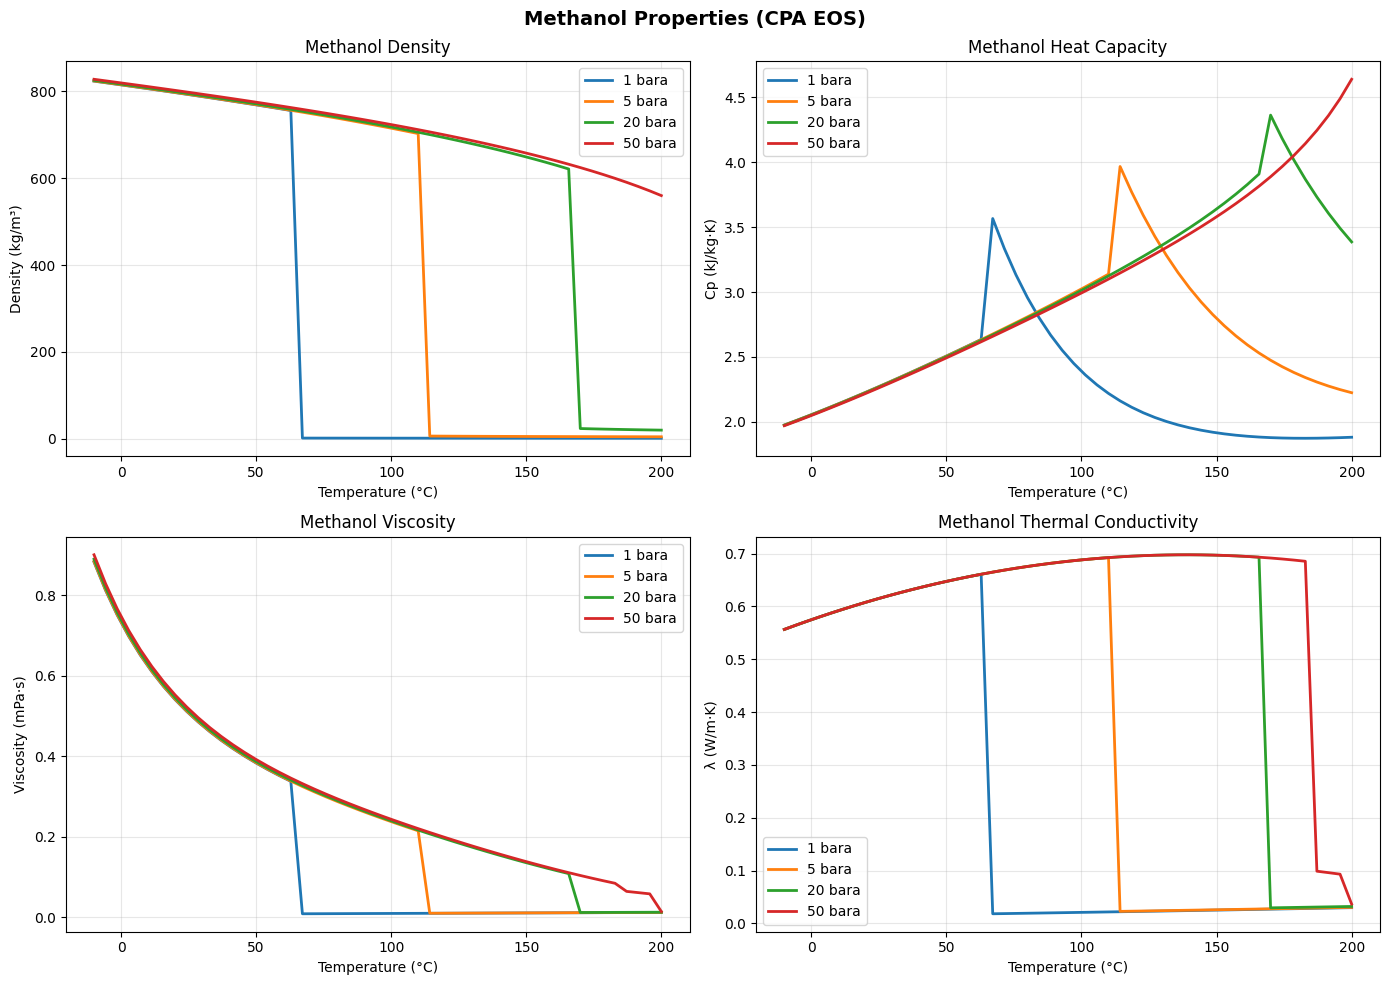

In [4]:
# Properties vs temperature at different pressures
temps = np.linspace(-10, 200, 50)
pressures = [1.0, 5.0, 20.0, 50.0]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for P in pressures:
    den = []
    cp = []
    visc = []
    therm_cond = []

    for t in temps:
        try:
            f = SystemSrkCPAstatoil(273.15 + float(t), float(P))
            f.addComponent('methanol', 1.0)
            f.setMixingRule('classic')
            ops = ThermodynamicOperations(f)
            ops.TPflash()
            f.initProperties()

            den.append(f.getDensity('kg/m3'))
            cp.append(f.getCp('kJ/kgK'))
            visc.append(f.getPhase(0).getViscosity('kg/msec') * 1000)  # mPa.s
            therm_cond.append(f.getPhase(0).getThermalConductivity('W/mK'))
        except Exception:
            den.append(float('nan'))
            cp.append(float('nan'))
            visc.append(float('nan'))
            therm_cond.append(float('nan'))

    label = f'{P:.0f} bara'
    axes[0, 0].plot(temps, den, label=label, linewidth=2)
    axes[0, 1].plot(temps, cp, label=label, linewidth=2)
    axes[1, 0].plot(temps, visc, label=label, linewidth=2)
    axes[1, 1].plot(temps, therm_cond, label=label, linewidth=2)

for ax, title, ylabel in [
    (axes[0, 0], 'Density', 'Density (kg/m³)'),
    (axes[0, 1], 'Heat Capacity', 'Cp (kJ/kg·K)'),
    (axes[1, 0], 'Viscosity', 'Viscosity (mPa·s)'),
    (axes[1, 1], 'Thermal Conductivity', 'λ (W/m·K)')]:
    ax.set_xlabel('Temperature (°C)')
    ax.set_ylabel(ylabel)
    ax.set_title(f'Methanol {title}')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Methanol Properties (CPA EOS)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('methanol_properties.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Methanol as Hydrate Inhibitor

Methanol is widely used as a thermodynamic hydrate inhibitor (THI) in gas production.
We calculate the hydrate formation temperature with and without methanol injection.

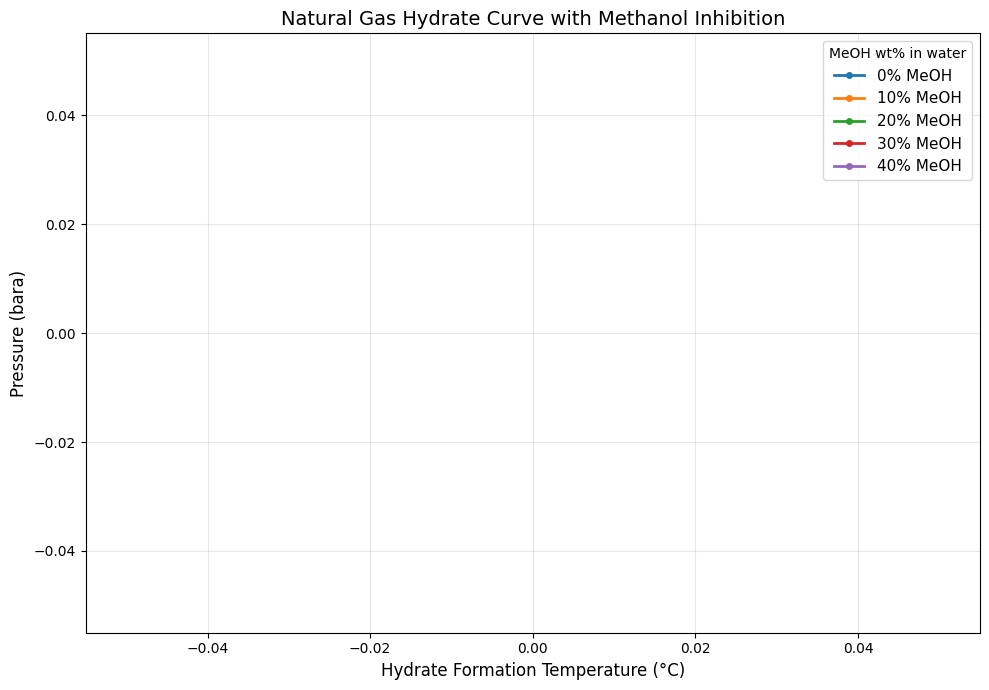

Figure saved: methanol_hydrate_inhibition.png


In [5]:
# Hydrate curve with methanol injection
meoh_wt_fracs = [0, 10, 20, 30, 40]  # wt% methanol in water phase

fig, ax = plt.subplots(figsize=(10, 7))

for meoh_wt in meoh_wt_fracs:
    pressures_hyd = np.arange(20, 250, 10)
    hydrate_temps = []

    for p in pressures_hyd:
        try:
            fluid = SystemSrkCPAstatoil(273.15 + 10.0, float(p))
            fluid.addComponent('methane', 80.0)
            fluid.addComponent('ethane', 10.0)
            fluid.addComponent('propane', 5.0)
            fluid.addComponent('CO2', 2.0)

            # Add water with methanol
            water_frac = 3.0 * (100 - meoh_wt) / 100.0
            meoh_frac = 3.0 * meoh_wt / 100.0
            fluid.addComponent('water', water_frac)
            if meoh_frac > 0.001:
                fluid.addComponent('methanol', meoh_frac)

            fluid.setMixingRule('classic')
            fluid.setMultiPhaseCheck(True)

            ops = ThermodynamicOperations(fluid)
            ops.hydrateFormationTemperature()
            hydrate_temps.append(fluid.getTemperature() - 273.15)
        except Exception:
            hydrate_temps.append(float('nan'))

    ax.plot(hydrate_temps, pressures_hyd, 'o-', linewidth=2, markersize=4,
            label=f'{meoh_wt}% MeOH')

ax.set_xlabel('Hydrate Formation Temperature (°C)', fontsize=12)
ax.set_ylabel('Pressure (bara)', fontsize=12)
ax.set_title('Natural Gas Hydrate Curve with Methanol Inhibition', fontsize=14)
ax.legend(title='MeOH wt% in water', fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('methanol_hydrate_inhibition.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: methanol_hydrate_inhibition.png')

## Summary

Key findings:

- **CPA EOS** is recommended for methanol systems due to strong hydrogen bonding
- Methanol-water system forms a minimum boiling azeotrope at very low methanol content
- Methanol is an effective hydrate inhibitor, reducing hydrate formation temperature
  by approximately 1°C per wt% at low concentrations
- Liquid methanol density at ambient: ~791 kg/m³

### Applications
- Hydrate inhibition dosing calculations
- Methanol recovery column design
- Rectisol process (CO₂ absorption)
- Marine fuel system design